# Stage 1: Leave-One-Out Cross-Validation

**Purpose:** Determine which objective function set best generalises to unseen storms.

## Workflow
1. Run SWMM for all 480 factor combinations across every storm event (checkpoint is saved after the first run — re-running this notebook is instant).
2. For each candidate objective set and each fold (one held-out storm):
   - Compute Pareto front on the N-1 training storms.
   - Select the Euclidean optimum.
   - Evaluate that optimum on the held-out storm.
3. Rank objective sets by mean validation error.

## Outputs (all inside `outputs/` — legacy directories are never modified)
| Path | Contents |
|------|----------|
| `outputs/results/loocv/loocv_calibration_cache.pkl` | Full calibration data (checkpoint) |
| `outputs/results/loocv/loocv_validation_summary.csv` | LOOCV summary table |
| `outputs/results/loocv/fold_*_*.pkl` | Per-fold checkpoints |


## How LOOCV Selects the Best Objective Set

**The key insight: SWMM runs happen once; everything else is pure arithmetic on cached data.**

### Step-by-step logic

1. **One-time SWMM run** — `run_calibration()` runs all N_combos × N_events SWMM simulations
   and caches the results (`loocv_calibration_cache.pkl`).  This is the only step that touches
   SWMM.  Every subsequent analysis reads from this cache.

2. **For each candidate objective set** (e.g. `['peak_1-kge', 'volume_1-kge', 'peak_rmsd', 'peak_bias']`):

   For each fold k = 0 … N_events−1:
   - **Training set** = cached results for the N−1 events excluding event k.
   - **Objective computation** = vectorised arithmetic on the cached peak/volume values.
   - **Pareto front** = O(n² × m) dominance check on the computed objective matrix.
   - **Euclidean optimum** = row closest to the origin in normalised objective space.
   - **Validation** = look up that parameter combination's simulated values for event k
     (already in the cache) and compare to the observed peak/volume.

3. **Ranking** — the set with the lowest mean held-out error across all 23 folds wins.

### Adding a new objective set = ZERO new SWMM runs

All 23 events × N_combos simulations are already in `loocv_calibration_cache.pkl`.
Adding a new candidate set to `CANDIDATE_OBJECTIVE_SETS` below only adds new arithmetic
operations on the cached numbers.  No `.inp` files are written, no SWMM process is launched.

The per-fold pickles (`fold_NN_setname.pkl`) serve as checkpoints so an interrupted LOOCV
run can resume from the last completed fold without re-computing completed folds.

In [1]:
# ── Configuration ────────────────────────────────────────────────────────────
import sys
from pathlib import Path

sys.path.insert(0, str(Path('.').resolve()))

# Source data (read-only — never modified)
CV_DIR = Path(
    r'D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation'
)

# All generated files go here — organised by purpose
PROJECT_ROOT = Path('.')
WORK_DIR     = PROJECT_ROOT / 'outputs' / 'runs'    / 'loocv'
RESULTS_DIR  = PROJECT_ROOT / 'outputs' / 'results' / 'loocv'
PARETO_DIR   = PROJECT_ROOT / 'outputs' / 'pareto'  / 'loocv'
for _d in [WORK_DIR, RESULTS_DIR, PARETO_DIR]:
    _d.mkdir(parents=True, exist_ok=True)

CALIBRATION_CACHE = RESULTS_DIR / 'loocv_calibration_cache.pkl'

# Candidate objective sets to compare.
# 'legacy_winner' replicates the selection from notebook 04 exactly.
CANDIDATE_OBJECTIVE_SETS = {
    'legacy_winner':         ['peak_1-kge', 'volume_1-kge', 'peak_rmsd', 'peak_bias'],
    'peak_kge_volume_kge':   ['peak_1-kge', 'volume_1-kge'],
    'peak_rmsd_volume_rmsd': ['peak_rmsd',  'volume_rmsd'],
    'all_peak':              ['peak_1-kge', 'peak_rmsd', 'peak_bias', 'peak_mad'],
}

print('Configuration loaded.')
print(f'  CV source dir  : {CV_DIR}')
print(f'  SWMM runs dir  : {WORK_DIR}')
print(f'  Results dir    : {RESULTS_DIR}')
print(f'  Objective sets : {list(CANDIDATE_OBJECTIVE_SETS)}')


Configuration loaded.
  CV source dir  : D:\Development\RESEARCH\Raanana\SWMM\from_radar\Cross_validation
  SWMM runs dir  : outputs\runs\loocv
  Results dir    : outputs\results\loocv
  Objective sets : ['legacy_winner', 'peak_kge_volume_kge', 'peak_rmsd_volume_rmsd', 'all_peak']


In [2]:
# ── Imports ───────────────────────────────────────────────────────────────────
import pickle
import logging
import os
import numpy as np
import pandas as pd

from urban_runoff.config import PARAMETER_GRID
from urban_runoff.calibration.cross_validation import (
    build_factor_combinations,
    run_calibration,
)
from urban_runoff.calibration.loocv import run_full_loocv

logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s %(levelname)-8s %(name)s: %(message)s',
    datefmt='%H:%M:%S',
)
logger = logging.getLogger('loocv_notebook')


In [3]:
# ── Factor grid ───────────────────────────────────────────────────────────────
factor_combinations = build_factor_combinations()
param_names         = list(PARAMETER_GRID.keys())

print(f'Factor grid: {len(factor_combinations)} combinations x {len(param_names)} parameters')
print()
for name, spec in PARAMETER_GRID.items():
    print(f'  {name:<20}  {list(spec.values())}')


Factor grid: 1323 combinations x 8 parameters

  imperviousness        [np.float64(0.5), np.float64(0.75), np.float64(0.9), np.float64(1.0), np.float64(1.1), np.float64(1.25), np.float64(1.5)]
  storage               [np.float64(0.1), np.float64(0.5), np.float64(1.0), np.float64(3.0), np.float64(5.0), np.float64(7.0), np.float64(8.0)]
  width                 [np.float64(0.7), np.float64(1.0), np.float64(1.3)]
  n                     [np.float64(1.0)]
  pct_zero              [np.float64(1.0)]
  cn                    [np.float64(1.0)]
  pct_routed            [np.float64(0.0), np.float64(10.0), np.float64(15.0), np.float64(20.0), np.float64(25.0), np.float64(30.0), np.float64(35.0), np.float64(40.0), np.float64(45.0)]
  evaporation           [np.float64(4.0)]


In [ ]:
# ── Run calibration on all events, or load from checkpoint ────────────────────
if CALIBRATION_CACHE.exists():
    logger.info('Loading cached calibration results from %s', CALIBRATION_CACHE)
    with open(CALIBRATION_CACHE, 'rb') as _f:
        _cached = pickle.load(_f)
    cali_results_df_l = _cached['cali_results_df_l']
    hydrograph_df_l   = _cached['hydrograph_df_l']
    obs_hydrograph_df = _cached['obs_hydrograph_df']
    logger.info('Cache loaded: %d events, %d combos each.',
                len(cali_results_df_l), len(cali_results_df_l[0]))
else:
    n_events = sum(1 for e in os.listdir(CV_DIR) if e.split('_')[0].isdigit())
    logger.info(
        'No cache. Running calibration: %d events x %d combos = %d SWMM runs.',
        n_events, len(factor_combinations), n_events * len(factor_combinations)
    )
    logger.info('SWMM .inp/.out files -> %s  (legacy dirs untouched)', WORK_DIR)

    cali_results_df_l, hydrograph_df_l, obs_hydrograph_df = run_calibration(
        cv_dir=CV_DIR,
        factor_combinations=factor_combinations,
        param_names=param_names,
        work_dir=WORK_DIR,
    )

    with open(CALIBRATION_CACHE, 'wb') as _f:
        pickle.dump({
            'cali_results_df_l': cali_results_df_l,
            'hydrograph_df_l':   hydrograph_df_l,
            'obs_hydrograph_df': obs_hydrograph_df,
        }, _f)
    logger.info('Cache saved to %s', CALIBRATION_CACHE)

print(f'Events loaded  : {len(cali_results_df_l)}')
print(f'Combinations   : {len(cali_results_df_l[0])}')
print(f'Observed rows  : {len(obs_hydrograph_df)} (all events concatenated)')


00:07:47 INFO     loocv_notebook: No cache. Running calibration: 23 events x 1323 combos = 30429 SWMM runs.
00:07:47 INFO     loocv_notebook: SWMM .inp/.out files -> outputs\runs\loocv  (legacy dirs untouched)
00:07:47 INFO     urban_runoff.calibration.cross_validation: Processing event: 2012_01_13


In [ ]:
# ── Physical bounds filter (Directive 2) ─────────────────────────────────────
# Edit FILTER_BOUNDS in urban_runoff/config.py to restrict the search space.
# e.g.  "imperviousness": (1.0, 1.5)  drops all IMP factor rows below 1.0.
# Setting all values to None (default) keeps the full grid — no filtering.
#
# This filter is applied to cali_results_df_l and hydrograph_df_l so that
# all downstream LOOCV folds operate only within the physical bounds.
# Zero new SWMM runs are needed — only cached rows outside the bounds are dropped.

from urban_runoff.config import FILTER_BOUNDS
from urban_runoff.calibration.cross_validation import apply_filter_bounds_to_list

_n_before = len(cali_results_df_l[0])
cali_results_df_l = apply_filter_bounds_to_list(cali_results_df_l, FILTER_BOUNDS)
hydrograph_df_l   = apply_filter_bounds_to_list(hydrograph_df_l,   FILTER_BOUNDS)
_n_after  = len(cali_results_df_l[0])

print(f'Parameter filter applied.')
print(f'  Active bounds : { {k: v for k, v in FILTER_BOUNDS.items() if v is not None} or "none (full grid)"}')
print(f'  Rows before   : {_n_before}')
print(f'  Rows after    : {_n_after}  ({_n_before - _n_after} dropped)')


In [ ]:
# ── Full LOOCV across all candidate objective sets ────────────────────────────
# Per-fold checkpoints in RESULTS_DIR allow resuming interrupted runs.
loocv_summary = run_full_loocv(
    cali_results_df_l=cali_results_df_l,
    hydrograph_df_l=hydrograph_df_l,
    obs_hydrograph_df=obs_hydrograph_df,
    candidate_objective_sets=CANDIDATE_OBJECTIVE_SETS,
    results_dir=RESULTS_DIR,
)

print('\n=== LOOCV Validation Summary (sorted by mean peak relative error) ===')
print(loocv_summary[
    ['objectives', 'mean_peak_rel_err', 'std_peak_rel_err',
     'mean_vol_rel_err', 'std_vol_rel_err', 'n_folds']
].to_string())


23:45:39 INFO     urban_runoff.calibration.loocv: LOOCV: objective set 'legacy_winner' (4 objectives, 23 folds)
23:45:39 INFO     urban_runoff.calibration.loocv:   Fold  1/23 (2012_01_13): peak_rel_err=0.103, vol_rel_err=0.024
23:45:39 INFO     urban_runoff.calibration.loocv:   Fold  2/23 (2013_01_06): peak_rel_err=0.348, vol_rel_err=0.404
23:45:39 INFO     urban_runoff.calibration.loocv:   Fold  3/23 (2014_12_14): peak_rel_err=0.743, vol_rel_err=0.556
23:45:39 INFO     urban_runoff.calibration.loocv:   Fold  4/23 (2015_10_07): peak_rel_err=0.365, vol_rel_err=0.092
23:45:39 INFO     urban_runoff.calibration.loocv:   Fold  5/23 (2015_10_27): peak_rel_err=0.412, vol_rel_err=0.331
23:45:39 INFO     urban_runoff.calibration.loocv:   Fold  6/23 (2015_10_28): peak_rel_err=0.167, vol_rel_err=0.308
23:45:39 INFO     urban_runoff.calibration.loocv:   Fold  7/23 (2015_12_14): peak_rel_err=0.157, vol_rel_err=0.144
23:45:39 INFO     urban_runoff.calibration.loocv:   Fold  8/23 (2016_01_08): peak_r


=== LOOCV Validation Summary (sorted by mean peak relative error) ===
                                                           objectives  mean_peak_rel_err  std_peak_rel_err  mean_vol_rel_err  std_vol_rel_err  n_folds
obj_set_name                                                                                                                                          
peak_rmsd_volume_rmsd                          peak_rmsd, volume_rmsd           0.280124          0.241145          0.419908         0.450057       23
legacy_winner          peak_1-kge, volume_1-kge, peak_rmsd, peak_bias           0.281807          0.258104          0.446668         0.465381       23
peak_kge_volume_kge                          peak_1-kge, volume_1-kge           0.285376          0.244324          0.397538         0.404485       23
all_peak                   peak_1-kge, peak_rmsd, peak_bias, peak_mad           0.305262          0.297360          0.557421         0.575947       23


In [ ]:
# ── Identify winner and save summary ─────────────────────────────────────────
winning_set_name = loocv_summary.index[0]
winning_objs     = CANDIDATE_OBJECTIVE_SETS[winning_set_name]

summary_path = RESULTS_DIR / 'loocv_validation_summary.csv'
loocv_summary.to_csv(summary_path)

print(f'Winning set  : {winning_set_name!r}')
print(f'Objectives   : {winning_objs}')
print(f'Mean peak err: {loocv_summary.loc[winning_set_name, "mean_peak_rel_err"]:.4f}')
print(f'Mean vol  err: {loocv_summary.loc[winning_set_name, "mean_vol_rel_err"]:.4f}')
print()
print(f'Summary -> {summary_path}')
print('Next: open 02_Stage2_Final_Calibration.ipynb')


Winning set  : 'peak_rmsd_volume_rmsd'
Objectives   : ['peak_rmsd', 'volume_rmsd']
Mean peak err: 0.2801
Mean vol  err: 0.4199

Summary -> outputs\results\loocv\loocv_validation_summary.csv
Next: open 02_Stage2_Final_Calibration.ipynb


## Visualization

All plots are generated **directly from the calibration and LOOCV caches**.
No SWMM simulations are re-run.

| Figure | File |
|--------|------|
| Pareto front (all pairs, winning set) | `outputs/metrics/loocv_pareto_grid.png` |
| LOOCV objective set comparison | `outputs/metrics/loocv_objective_comparison.png` |
| Held-out validation scatter | `outputs/metrics/loocv_validation_scatter.png` |


In [ ]:
# ── Visualization setup ──────────────────────────────────────────────────────
# Objectives are computed from the already-loaded calibration cache.
# A secondary objectives cache avoids recomputing on subsequent runs.
import matplotlib
matplotlib.rcParams['figure.dpi'] = 100

from urban_runoff.calibration.cross_validation import merge_calibration_results
from urban_runoff.calibration.objectives       import (
    compute_objective_functions, build_objectives_dataframe,
)
from urban_runoff.optimization.pareto          import find_pareto_front, normalize_columns
from urban_runoff.optimization.selection       import closest_row_to_origin
from urban_runoff.visualization.pareto_plots   import plot_pareto_grid
from urban_runoff.visualization.scatter        import (
    plot_loocv_summary_bar, plot_loocv_validation_scatter,
)
import matplotlib.pyplot as plt

METRICS_DIR = PROJECT_ROOT / 'outputs' / 'metrics'
METRICS_DIR.mkdir(parents=True, exist_ok=True)

_full_obj_cache = RESULTS_DIR / 'loocv_full_objectives_cache.pkl'
if _full_obj_cache.exists():
    logger.info('Loading full-set objectives from cache: %s', _full_obj_cache)
    with open(_full_obj_cache, 'rb') as _f:
        _oc = pickle.load(_f)
    _storm_obj_df  = _oc['storm_obj_df']
    _peak_obj_df   = _oc['peak_obj_df']
    _volume_obj_df = _oc['volume_obj_df']
else:
    logger.info('Computing objectives on all %d events (one-time, ~10s)...', len(cali_results_df_l))
    _cali_merged  = merge_calibration_results(cali_results_df_l)
    _hydro_merged = merge_calibration_results(hydrograph_df_l)
    _storm_obj_df, _peak_obj_df, _volume_obj_df = compute_objective_functions(
        obs_hydrograph_df, _cali_merged, _hydro_merged
    )
    with open(_full_obj_cache, 'wb') as _f:
        pickle.dump({
            'storm_obj_df':  _storm_obj_df,
            'peak_obj_df':   _peak_obj_df,
            'volume_obj_df': _volume_obj_df,
        }, _f)
    logger.info('Objectives cached to %s', _full_obj_cache)

_objectives_flat = build_objectives_dataframe(
    _storm_obj_df, _peak_obj_df, _volume_obj_df, objective_names=winning_objs
)
_objectives_norm = normalize_columns(_objectives_flat.abs())
_pareto_df       = find_pareto_front(_objectives_flat, normalize=True)
_pareto_norm     = _objectives_norm.loc[_pareto_df.index]
_optimum_row     = closest_row_to_origin(_pareto_df)
_optimum_norm    = _objectives_norm.loc[_optimum_row.name]

print(f'Objective combinations : {len(_objectives_norm)}')
print(f'Pareto front (winning) : {len(_pareto_df)} points')
print(f'Winning objectives     : {winning_objs}')


23:45:40 INFO     loocv_notebook: Loading full-set objectives from cache: outputs\results\loocv\loocv_full_objectives_cache.pkl
23:45:40 INFO     urban_runoff.optimization.pareto: find_pareto_front: 6/480 solutions are Pareto-optimal (1.2%)


Objective combinations : 480
Pareto front (winning) : 6 points
Winning objectives     : ['peak_rmsd', 'volume_rmsd']


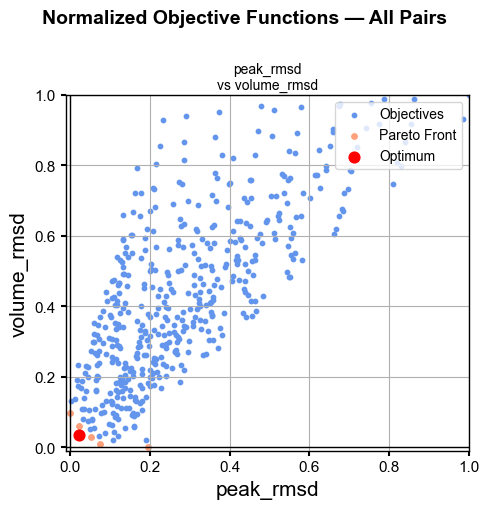

Saved -> outputs\metrics\loocv_pareto_grid.png


In [ ]:
# ── Plot 1: Pareto front — all pairs (winning objective set) ─────────────────
fig_pareto = plot_pareto_grid(
    objectives_df   = _objectives_norm,
    pareto_df       = _pareto_norm,
    optimum_row     = _optimum_norm,
    objective_names = winning_objs,
    save_path       = str(METRICS_DIR / 'loocv_pareto_grid.png'),
)
plt.show()
print(f'Saved -> {METRICS_DIR / "loocv_pareto_grid.png"}')


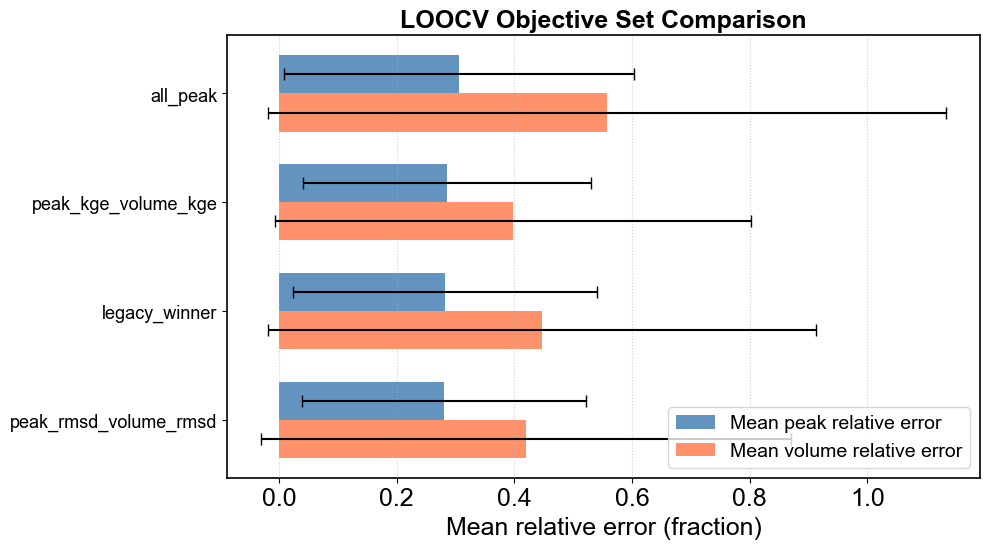

Saved -> outputs\metrics\loocv_objective_comparison.png


In [ ]:
# ── Plot 2: LOOCV objective set comparison bar chart ─────────────────────────
fig_bar = plot_loocv_summary_bar(
    loocv_summary,
    save_path = str(METRICS_DIR / 'loocv_objective_comparison.png'),
)
plt.show()
print(f'Saved -> {METRICS_DIR / "loocv_objective_comparison.png"}')


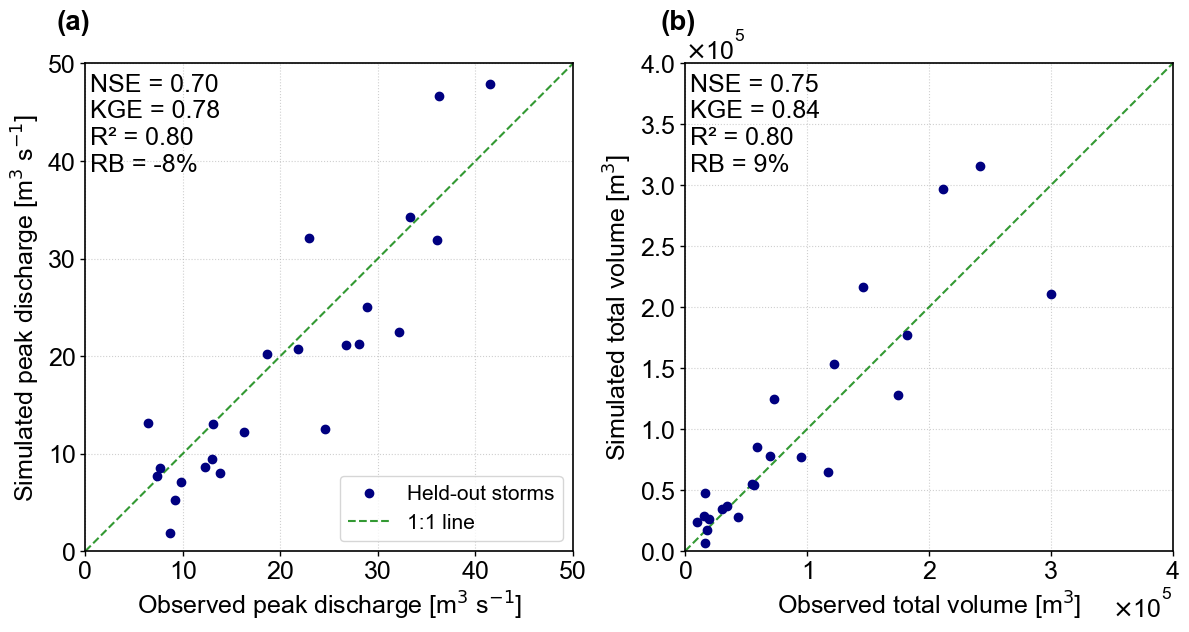

Saved -> outputs\metrics\loocv_validation_scatter.png
Held-out storms shown : 23


In [ ]:
# ── Plot 3: Held-out validation scatter (all LOOCV folds) ────────────────────
# Each of the N folds contributes one held-out (obs, sim) point.
# Loads per-fold checkpoint pickles — no computation needed.
_all_folds_path = RESULTS_DIR / f'all_folds_{winning_set_name}.pkl'
if not _all_folds_path.exists():
    raise FileNotFoundError(
        f'Fold results not found: {_all_folds_path}\n'
        'Run the LOOCV cells above first.'
    )
with open(_all_folds_path, 'rb') as _f:
    _fold_results = pickle.load(_f)

fig_vali = plot_loocv_validation_scatter(
    fold_results = _fold_results,
    save_path    = str(METRICS_DIR / 'loocv_validation_scatter.png'),
)
plt.show()
print(f'Saved -> {METRICS_DIR / "loocv_validation_scatter.png"}')
print(f'Held-out storms shown : {len(_fold_results)}')
